In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 72.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2d6df568261c6126377ee245ae09ca0118508aed6039e077046bd2da5e56e966
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


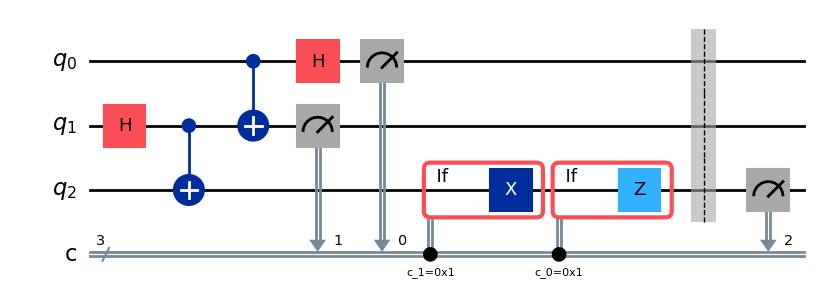

In [17]:
# Teleportation
# Create a circuit with 3 qubits (first parameter) and 3 classical bits (second parameter)
teleport = QuantumCircuit(3,3)

# qubit 0 is the state to be teleported from Alice (right side)
# qubits 1 and 2 are the shared entangled state
# Alice has qubit 1, Bob has qubit 2

# Add gates here to entangle qubits 1 and 2
teleport.h(1)
teleport.cx(1,2)

# Add gates here to entangle qubit 0 with the others
teleport.cx(0,1)
teleport.h(0)



# Measure qubits 0 and 1 and put the results on classical bits 0 and 1.
teleport.measure([0,1],[0,1])

# Fix up the final state of qubit 2, depending on the measurement results.
# Here we are using a feature of Qiskit that we haven't seen before.
# if_test((classical_bit, value)) - basically see if the value of the classical bit
# apply X if cbit 1 is 1
with teleport.if_test((1, 1)):
    teleport.x(2)
# apply z if cbit 0 is 1
with teleport.if_test((0, 1)):
    teleport.z(2)



# Sometimes it's useful to insert a "barrier" to make the diagram clearer.
# A barrier also has an effect on how the circuit is compiled, but we won't worry about that.
teleport.barrier()

# Measure qubit 2 (first parameter) and put the result on classical bit 2 (second parameter)
teleport.measure([2],[2])

# Check the circuit
teleport.draw("mpl")

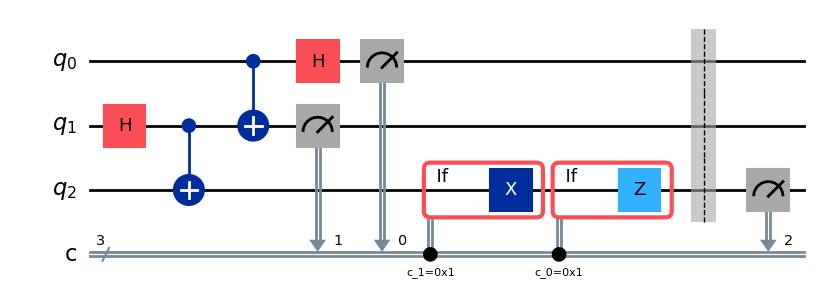

In [18]:
# Use a circuit to put qubit 0 into the state that we want to teleport,
# and compose it into the main circuit.

prep = QuantumCircuit(1)
# Add a gate here to put qubit 0 into some state other than |0>
# prep.x(0)
prep.h(0)

# When we compose circuits, the second parameter is the list of qubits (wires) that are being connected
teleport = teleport.compose(prep, [0], front=True)
teleport.draw("mpl")

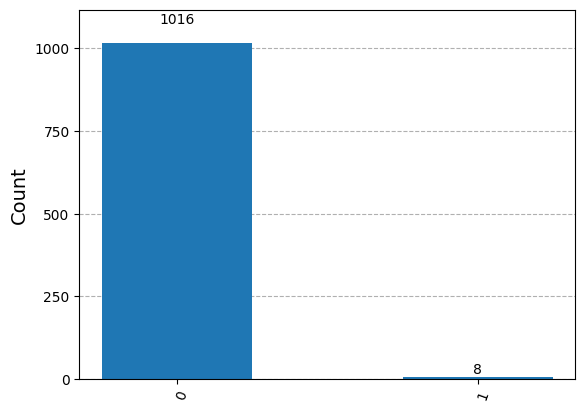

In [20]:
# Now simulate and plot the results.
# In general this won't tell us that we have exactly the right state,
# just that we get the right measurement statistics.
# We are interested in the result on classical bit 2, which is the most significant bit (leftmost).
# The simulator adds some noise, so we get some non-zero probabilities for parts of bit 2 that shouldn't be there.
# To see results without noise, add the parameter noise_info=False to GenericBackendV2
# We need to use GenericBackendV2 instead of BasicSimulator, and set control_flow=True, so that we can use if_test.

backend = GenericBackendV2(num_qubits=3, control_flow=True)
compiled = transpile(teleport, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts,indices=[2]) # We only want to see the results for bit 2
plot_histogram(mcounts)

# if prep is set to h, count will be 50/50 btween 0/1
# if prep set to x (initial state is |0>) count will be 1 else 0

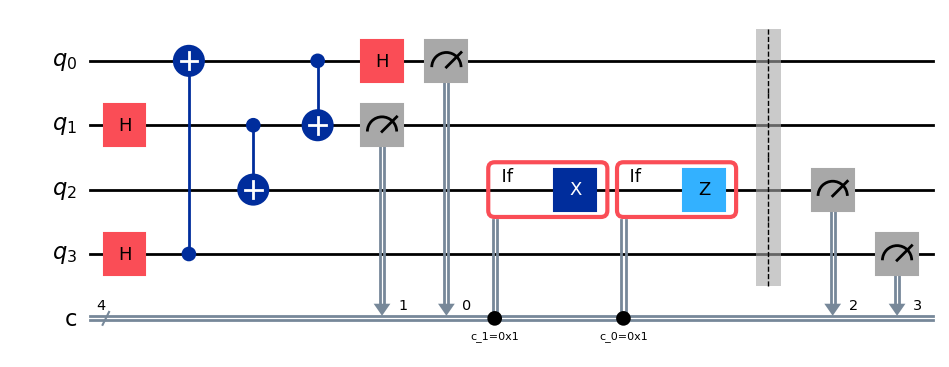

In [33]:
# Teleportation has an interesting feature which is not usually
# included in the description.

# If the qubit being teleported is entangled with other qubits, then after
# teleportation it is still entangled in the same way.

# Try this out!
# You will need to introduce another qubit and entangle it with qubit 0.
# After teleporting, work out how to use measurements to convince yourself that qubit 2 is entangled with the extra qubit.
# You can do this in a similar way to the exercise in Lab1 about Bell states.

teleport_swapping = QuantumCircuit(4, 4)
teleport_swapping.h(3)
teleport_swapping.cx(3, 0)

teleport_swapping.h(1)
teleport_swapping.cx(1, 2)

teleport_swapping.cx(0, 1)
teleport_swapping.h(0)

teleport_swapping.measure([0, 1], [0, 1])

# apply X if cbit 1 is 1
with teleport_swapping.if_test((1, 1)):
    teleport_swapping.x(2)
# apply z if cbit 0 is 1
with teleport_swapping.if_test((0, 1)):
    teleport_swapping.z(2)

teleport_swapping.barrier()

teleport_swapping.measure([2], [2])
teleport_swapping.measure(3, 3)

teleport_swapping.draw("mpl")




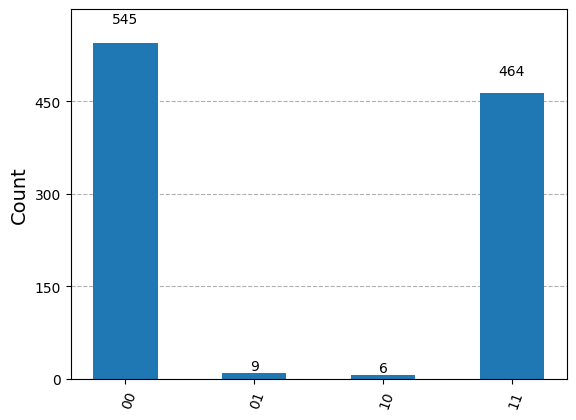

In [41]:

backend = GenericBackendV2(num_qubits=4, control_flow=True)
compiled = transpile(teleport_swapping, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts,indices=[2,3]) # We only want to see the results for bit 2
plot_histogram(mcounts)

# backend = GenericBackendV2(num_qubits=4, control_flow=True, noise_info=False)
# compiled = transpile(teleport_swapping, backend)
# counts = backend.run(compiled).result().get_counts()

# # We only care about bits 2 and 3 (the correlation between Bob and the Partner)
# swapped_counts = marginal_counts(counts, indices=[2, 3])
# plot_histogram(swapped_counts)

In [ ]:
#